#Laboratorio 3
##Nombre: Carlos Alberto Aucu Gomez

#Problema
Eres parte de un equipo que desarrolla un sistema de logistica de entregas en una ciudad. Tienes coordenadas (x,y) de 10.000 puntos de entrega (estos datos los puedes tomar de datos reales o generarlos, para este ejercicio los dados son estaticos, no cambian)

Necesitas implementar un sistema que responda eficientemente preguntas como:
- ¿Que puntos de entrega estan a un radio de 500 metros de un punto dado? (tener en cuenta unidades)
- ¿Cual es o son los puntos de entrega mas cercano a una ubicacion dada?

##Objetivo: implementar un Quad-Tree desde cero, y comparar con fuerza bruta.

##Micro-tareas para resolver el ejercicio:
- Construir el Quad-Tree (no se pueden usar arboles ya generados o librerias como scipy)
- Implementar busqueda dentro de un radio (Range Search)
- Vecinos (puntos encontrados dentro del radio) y encontrar los mas cercanos
- Verificacion visual de radio y puntos encontrados dentro del radio
- Verificacion visual de los vecinos mas cercanos.
- IMPORTANTE: trate de hacer el codigo para K-dimensiones, sino, puede ser solo para 2D
- No se permiten soluciones completas de internet o vibe coding, si se puede apoyar de IA o internet



#Codigo:

#Generar los datos y el nodo del arbol
Para simular la ciudad, generamos 10.000 puntos aleatorios dentro de un área de 10 km × 10 km. Las coordenadas están en metros, lo que significa que cuando digamos "radio de 500", eso equivale directamente a 500 metros reales.

In [ ]:
import random
import math

#1. generar datos
random.seed(42)

num_puntos = 10000
ciudad_m = 10000

puntos = [(random.uniform(0, ciudad_m), random.uniform(0, ciudad_m)) for _ in range(num_puntos) ]

#2. distancia
def distancia(p1, p2):
    return math.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)

Cada punto de entrega vive en un Nodo. Un Nodo guarda tres cosas: el punto en sí con sus coordenadas (ej: (x,y)), los límites del área rectangular que representa ese nodo en el mapa (lista de pares min y max por cada dimension, ej en 2D: [(x_min, x_max), (y_min, y_max)]) , y una lista de hijos, uno por cada cuadrante en que se divide esa área.


In [ ]:
#3. nodo del arbol quad-tree
class NodoQuad:
    def __init__(self, punto, x_min, x_max, y_min, y_max):
        self.punto = punto
        self.x_min = x_min
        self.x_max = x_max
        self.y_min = y_min
        self.y_max = y_max

        self.no = None  # noroeste: x izquierda, y arriba
        self.ne = None  # noreste:  x derecha,   y arriba
        self.so = None  # suroeste: x izquierda, y abajo
        self.se = None  # sureste:  x derecha,   y abajo


#Crear el Quad-Tree
La construcción se basa en dividir el espacio de forma uniforme. En cada paso se toma el área actual, se calcula su punto central, y el punto de entrega más cercano a ese centro se convierte en la raíz del nodo. Luego todos los demás puntos se distribuyen en los cuadrantes según su posición respecto al centro, y el mismo proceso se repite recursivamente para cada cuadrante con sus nuevos límites.

El resultado es un árbol donde el espacio queda dividido en regiones cuadradas anidadas. Esto es lo que permite después descartar zonas enteras durante una búsqueda sin tener que revisarlas.

In [ ]:
#4. construir quad-tree

def construir_quadtree(puntos, x_min=0, x_max=ciudad_m,
                                y_min=0, y_max=ciudad_m):
    if not puntos:
        return None

    # eentro del área actual = punto de corte
    cx = (x_min + x_max) / 2
    cy = (y_min + y_max) / 2

    # el punto más cercano al centro es la raíz de este nodo
    raiz_punto = min(puntos, key=lambda p: distancia(p, (cx, cy)))
    nodo = NodoQuad(raiz_punto, x_min, x_max, y_min, y_max)

    # distribuir los puntos en sus cuadrantes
    no, ne, so, se = [], [], [], []
    for p in puntos:
        if p == raiz_punto:
            continue
        if p[0] <  cx and p[1] >= cy:
            no.append(p)
        elif p[0] >= cx and p[1] >= cy:
            ne.append(p)
        elif p[0] <  cx and p[1] <  cy:
            so.append(p)
        else:
            se.append(p)

    nodo.no = construir_quadtree(no, x_min, cx,    cy,    y_max)
    nodo.ne = construir_quadtree(ne, cx,    x_max, cy,    y_max)
    nodo.so = construir_quadtree(so, x_min, cx,    y_min, cy)
    nodo.se = construir_quadtree(se, cx,    x_max, y_min, cy)

    return nodo

In [ ]:
#Prueba
raiz = construir_quadtree(puntos)

print(f"Raíz del árbol : {raiz.punto}")
print(f"Hijo nor-oeste : {raiz.no.punto}")
print(f"Hijo nor-este  : {raiz.ne.punto}")
print(f"Hijo sur-oeste : {raiz.so.punto}")
print(f"Hijo sur-este  : {raiz.se.punto}")

#Busqueda por radio (Range Search)
Dado un punto de consulta y un radio de 500 metros, queremos encontrar todos los puntos del árbol que estén dentro de ese círculo.

La búsqueda recorre el árbol de arriba hacia abajo. En cada nodo hace dos cosas. Primero verifica si el punto que vive en ese nodo está dentro del radio. Segundo, y esto es lo más importante, decide si vale la pena explorar los cuadrantes hijos.

Aquí entra la poda: antes de explorar cualquier nodo, se pregunta si el círculo de búsqueda se intersecta con el área rectangular que representa ese nodo. Si el círculo no toca el rectángulo, todos los puntos dentro de ese nodo y de todos sus hijos están definitivamente fuera del radio, y se ignoran por completo con una sola verificación.
Para saber si el círculo toca el rectángulo se encuentra el punto del rectángulo más cercano al centro del círculo. Esto se hace limitando la posición de la consulta a los bordes del rectángulo en cada dimensión. Si ese punto está dentro del radio, el círculo toca el rectángulo y hay que explorar ese nodo. Si no, se descarta todo el cuadrante.

In [ ]:
#6. Radio intersecta rectangulo ?

def circulo_intersecta_rectangulo(consulta, radio, x_min, x_max, y_min, y_max):
    # punto del rectángulo más cercano a la consulta
    px = max(x_min, min(consulta[0], x_max))
    py = max(y_min, min(consulta[1], y_max))
    return distancia(consulta, (px, py)) <= radio


def busqueda_radio_quad(nodo, consulta, radio, encontrados=None):
    if encontrados is None:
        encontrados = []

    if nodo is None:
        return encontrados

    # Poda: si el círculo no toca el área de este nodo, ignorar todo
    if not circulo_intersecta_rectangulo(consulta, radio,
                                         nodo.x_min, nodo.x_max,
                                         nodo.y_min, nodo.y_max):
        return encontrados

    # el punto de este nodo está dentro del radio?
    if distancia(consulta, nodo.punto) <= radio:
        encontrados.append(nodo.punto)

    # explorar los 4 cuadrantes
    busqueda_radio_quad(nodo.no, consulta, radio, encontrados)
    busqueda_radio_quad(nodo.ne, consulta, radio, encontrados)
    busqueda_radio_quad(nodo.so, consulta, radio, encontrados)
    busqueda_radio_quad(nodo.se, consulta, radio, encontrados)

    return encontrados


In [ ]:
"""
#Prueba
"""
punto_consulta = (5000.0, 5000.0)
radio_metros   = 500

resultado = busqueda_radio_quad(raiz, punto_consulta, radio_metros)
print(f"Puntos encontrados dentro de {radio_metros}m: {len(resultado)}")
print(f"Primeros 3: {resultado[:3]}")

#Vecinos (puntos encontrados dentro del radio) y encontrar los mas cercanos

El objetivo es encontrar el único punto más cercano al punto de consulta, sin importar a qué distancia esté.

La lógica es la misma que la búsqueda por radio, con dos diferencias. Primero, no hay radio fijo. En su lugar se lleva un mejor candidato que arranca con distancia infinita y se actualiza cada vez que se encuentra un punto más cercano. La distancia a ese candidato actúa como radio dinámico que se va acortando durante el recorrido, permitiendo descartar cada vez más cuadrantes.

El orden de exploración importa. Primero se explora el cuadrante donde cae el punto de consulta, porque es el más probable de contener el vecino más cercano. Eso achica el radio más rápido y permite que la poda descarte más cuadrantes en los pasos siguientes. Al final del recorrido, el mejor candidato es el vecino más cercano.

In [ ]:
#7 vecino mas cercano
def vecino_mas_cercano_quad(nodo, consulta, mejor=None):
    if mejor is None:
        mejor = [None, float('inf')]

    if nodo is None:
        return mejor

    # poda: si el área está más lejos que el mejor candidato, ignorar
    if not circulo_intersecta_rectangulo(consulta, mejor[1],
                                         nodo.x_min, nodo.x_max,
                                         nodo.y_min, nodo.y_max):
        return mejor

    # este nodo mejora el candidato actual?
    dist_actual = distancia(consulta, nodo.punto)
    if dist_actual < mejor[1]:
        mejor[0] = nodo.punto
        mejor[1] = dist_actual

    # determinar cuál cuadrante contiene la consulta
    cx = (nodo.x_min + nodo.x_max) / 2
    cy = (nodo.y_min + nodo.y_max) / 2

    # explorar primero el cuadrante donde cae la consulta
    if consulta[0] < cx and consulta[1] >= cy:
        orden = [nodo.no, nodo.ne, nodo.so, nodo.se]
    elif consulta[0] >= cx and consulta[1] >= cy:
        orden = [nodo.ne, nodo.no, nodo.se, nodo.so]
    elif consulta[0] < cx and consulta[1] < cy:
        orden = [nodo.so, nodo.se, nodo.no, nodo.ne]
    else:
        orden = [nodo.se, nodo.so, nodo.ne, nodo.no]

    for hijo in orden:
        vecino_mas_cercano_quad(hijo, consulta, mejor)

    return mejor



In [ ]:
"""
#Prueba
"""
punto_consulta = (5000.0, 5000.0)

resultado        = vecino_mas_cercano_quad(raiz, punto_consulta)
punto_cercano    = resultado[0]
distancia_cercana = resultado[1]

print(f"Punto de consulta  : {punto_consulta}")
print(f"Vecino más cercano : {punto_cercano}")
print(f"Distancia          : {distancia_cercana:.2f}")

Punto de consulta  : (5000.0, 5000.0)
Vecino más cercano : (5031.525482082876, 4997.266987431037)
Distancia          : 31.64


#Visualizaciones


##Verificacion visual de radio y puntos encontrados dentro del radio.

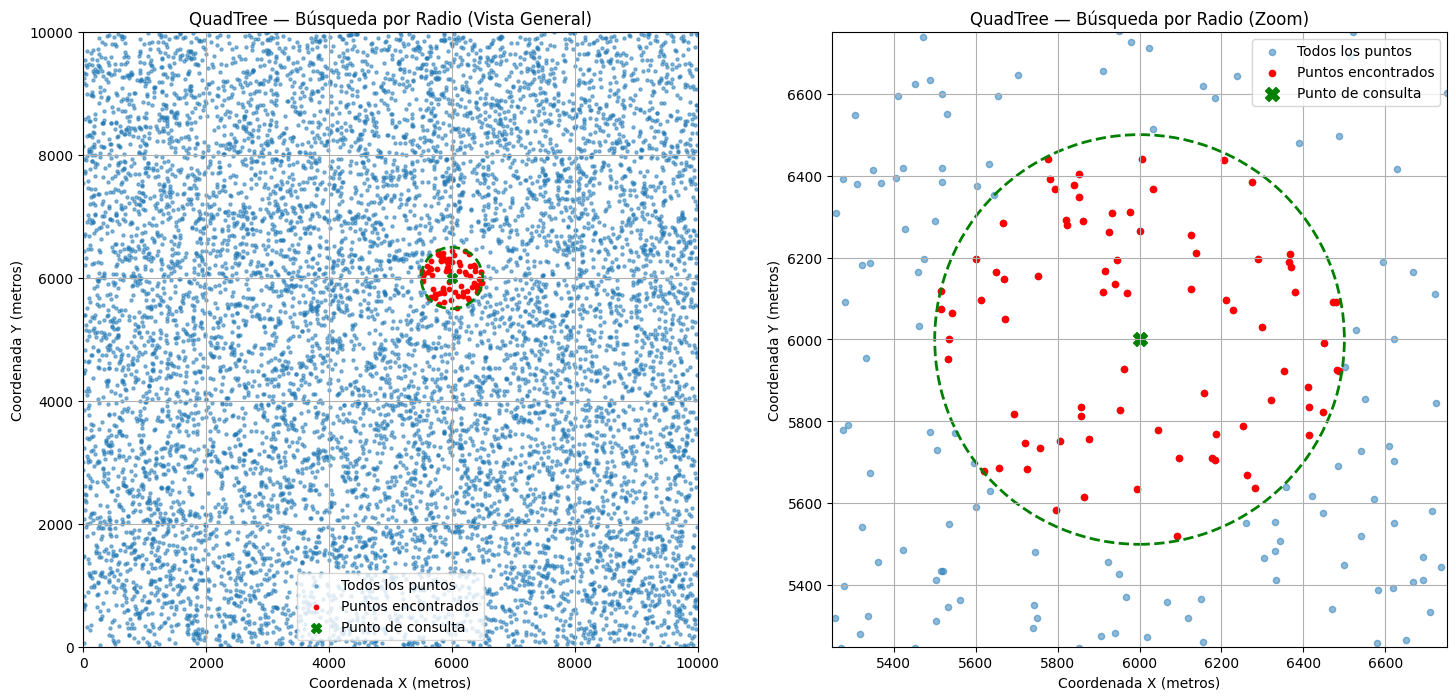

In [ ]:
import matplotlib.pyplot as plt

def visualizar_busqueda_radio(puntos_totales, punto_consulta,
                               radio_busqueda, puntos_encontrados, ciudad_m):
    fig, axs = plt.subplots(1, 2, figsize=(15, 7))

    x_totales     = [p[0] for p in puntos_totales]
    y_totales     = [p[1] for p in puntos_totales]
    x_encontrados = [p[0] for p in puntos_encontrados]
    y_encontrados = [p[1] for p in puntos_encontrados]

    # ── Gráfica general ───────────────────────────────────────────
    axs[0].scatter(x_totales, y_totales, s=5, alpha=0.5,
                   label='Todos los puntos')
    axs[0].scatter(x_encontrados, y_encontrados, s=10, color='red',
                   label='Puntos encontrados')
    axs[0].scatter(punto_consulta[0], punto_consulta[1], s=50,
                   color='green', marker='X', label='Punto de consulta')

    circulo = plt.Circle(punto_consulta, radio_busqueda, color='green',
                         fill=False, linestyle='--', linewidth=2)
    axs[0].add_patch(circulo)

    axs[0].set_title('QuadTree — Búsqueda por Radio (Vista General)')
    axs[0].set_xlabel('Coordenada X (metros)')
    axs[0].set_ylabel('Coordenada Y (metros)')
    axs[0].set_xlim(0, ciudad_m)
    axs[0].set_ylim(0, ciudad_m)
    axs[0].set_aspect('equal', adjustable='box')
    axs[0].legend()
    axs[0].grid(True)

    # ── Gráfica con zoom ──────────────────────────────────────────
    axs[1].scatter(x_totales, y_totales, s=20, alpha=0.5,
                   label='Todos los puntos')
    axs[1].scatter(x_encontrados, y_encontrados, s=20, color='red',
                   label='Puntos encontrados')
    axs[1].scatter(punto_consulta[0], punto_consulta[1], s=100,
                   color='green', marker='X', label='Punto de consulta')

    circulo_zoom = plt.Circle(punto_consulta, radio_busqueda, color='green',
                              fill=False, linestyle='--', linewidth=2)
    axs[1].add_patch(circulo_zoom)

    axs[1].set_title('QuadTree — Búsqueda por Radio (Zoom)')
    axs[1].set_xlabel('Coordenada X (metros)')
    axs[1].set_ylabel('Coordenada Y (metros)')
    zoom_margin = radio_busqueda * 1.5
    axs[1].set_xlim(punto_consulta[0] - zoom_margin, punto_consulta[0] + zoom_margin)
    axs[1].set_ylim(punto_consulta[1] - zoom_margin, punto_consulta[1] + zoom_margin)
    axs[1].set_aspect('equal', adjustable='box')
    axs[1].legend()
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()


# ── PRUEBA ────────────────────────────────────────────────────────
punto_consulta = (6000.0, 6000.0)
radio_busqueda = 500
resultados     = busqueda_radio_quad(raiz, punto_consulta, radio_busqueda)

visualizar_busqueda_radio(puntos, punto_consulta, radio_busqueda, resultados, ciudad_m)

##Verificacion visual de los vecinos mas cercanos.

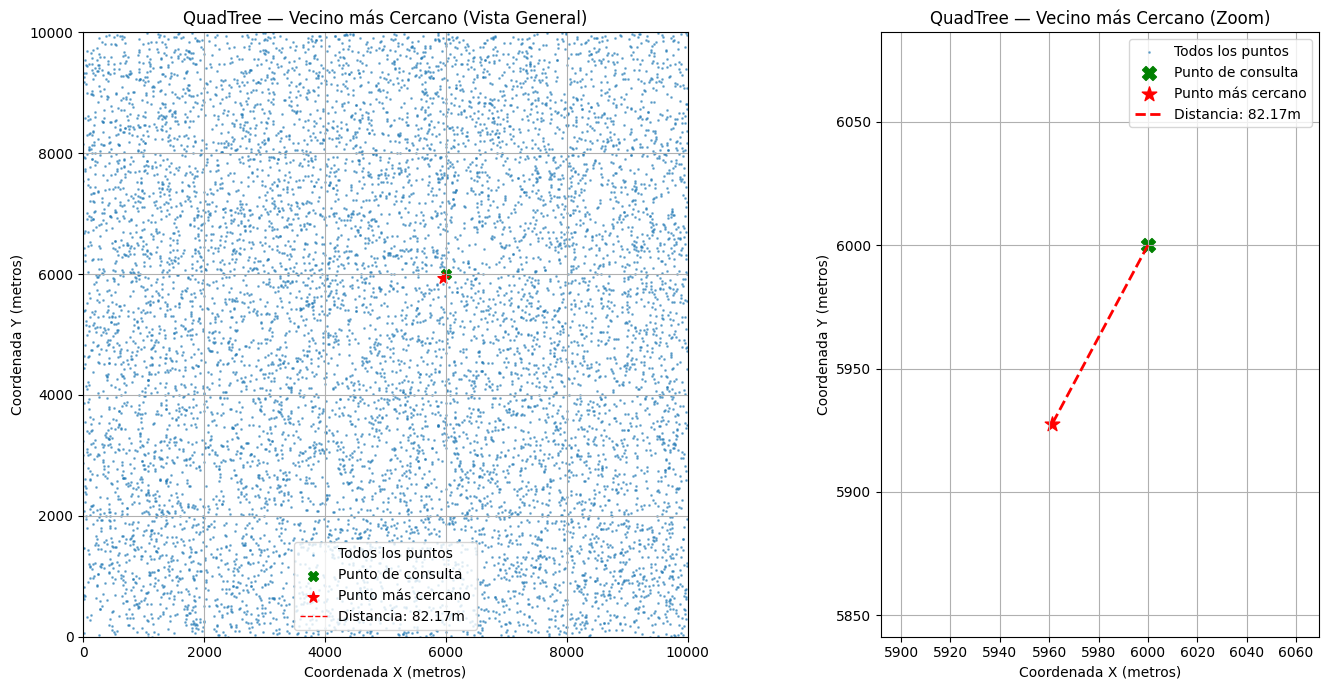

In [ ]:
def visualizar_vecino_mas_cercano(puntos_totales, punto_consulta,
                                   punto_cercano, distancia_cercana, ciudad_m):
    fig, axs = plt.subplots(1, 2, figsize=(15, 7))

    x_totales = [p[0] for p in puntos_totales]
    y_totales = [p[1] for p in puntos_totales]

    # ── Gráfica general ───────────────────────────────────────────
    axs[0].scatter(x_totales, y_totales, s=1, alpha=0.5,
                   label='Todos los puntos')
    axs[0].scatter(punto_consulta[0], punto_consulta[1], s=50,
                   color='green', marker='X', label='Punto de consulta')
    axs[0].scatter(punto_cercano[0], punto_cercano[1], s=70,
                   color='red', marker='*', label='Punto más cercano')
    axs[0].plot([punto_consulta[0], punto_cercano[0]],
                [punto_consulta[1], punto_cercano[1]],
                color='red', linestyle='--', linewidth=1,
                label=f'Distancia: {distancia_cercana:.2f}m')

    axs[0].set_title('QuadTree — Vecino más Cercano (Vista General)')
    axs[0].set_xlabel('Coordenada X (metros)')
    axs[0].set_ylabel('Coordenada Y (metros)')
    axs[0].set_xlim(0, ciudad_m)
    axs[0].set_ylim(0, ciudad_m)
    axs[0].set_aspect('equal', adjustable='box')
    axs[0].legend()
    axs[0].grid(True)

    # ── Gráfica con zoom ──────────────────────────────────────────
    axs[1].scatter(x_totales, y_totales, s=1, alpha=0.5,
                   label='Todos los puntos')
    axs[1].scatter(punto_consulta[0], punto_consulta[1], s=100,
                   color='green', marker='X', label='Punto de consulta')
    axs[1].scatter(punto_cercano[0], punto_cercano[1], s=120,
                   color='red', marker='*', label='Punto más cercano')
    axs[1].plot([punto_consulta[0], punto_cercano[0]],
                [punto_consulta[1], punto_cercano[1]],
                color='red', linestyle='--', linewidth=2,
                label=f'Distancia: {distancia_cercana:.2f}m')

    axs[1].set_title('QuadTree — Vecino más Cercano (Zoom)')
    axs[1].set_xlabel('Coordenada X (metros)')
    axs[1].set_ylabel('Coordenada Y (metros)')

    min_x = min(punto_consulta[0], punto_cercano[0])
    max_x = max(punto_consulta[0], punto_cercano[0])
    min_y = min(punto_consulta[1], punto_cercano[1])
    max_y = max(punto_consulta[1], punto_cercano[1])

    zoom_margin_x = abs(max_x - min_x) * 0.5 + 50
    zoom_margin_y = abs(max_y - min_y) * 0.5 + 50

    axs[1].set_xlim(min_x - zoom_margin_x, max_x + zoom_margin_x)
    axs[1].set_ylim(min_y - zoom_margin_y, max_y + zoom_margin_y)
    axs[1].set_aspect('equal', adjustable='box')
    axs[1].legend()
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()


# ── PRUEBA ────────────────────────────────────────────────────────
resultado        = vecino_mas_cercano_quad(raiz, punto_consulta)
punto_cercano    = resultado[0]
distancia_cercana = resultado[1]

visualizar_vecino_mas_cercano(puntos, punto_consulta,
                               punto_cercano, distancia_cercana, ciudad_m)

#Analisis comparativo:
¿Para que tamaño de datos el quad-tree comienza a ser mas rapido que "fuerza bruta" (no arboles, si listas, ...)?

La fuerza bruta simplemente recorre todos los puntos uno por uno y calcula la distancia a cada uno. Es la solución más directa posible.
Sirve para dos cosas en este laboratorio. Primero, verificar que el QuadTree está dando los resultados correctos: ambos métodos deben encontrar exactamente los mismos puntos. Segundo, medir la diferencia de velocidad entre los dos enfoques.



In [ ]:
import timeit

# fuerza bruta radio
def busqueda_radio_fuerza_bruta(puntos, consulta, radio):
    encontrados_fb = []
    for p in puntos:
        if distancia(consulta, p) <= radio:
            encontrados_fb.append(p)
    return encontrados_fb

def vecino_mas_cercano_fuerza_bruta(puntos, consulta):
    mejor_punto     = None
    menor_distancia = float('inf')
    for p in puntos:
        dist = distancia(consulta, p)
        if dist < menor_distancia:
            menor_distancia = dist
            mejor_punto     = p
    return mejor_punto, menor_distancia

# verificar que el quad-tree y la fuerza bruta dan el mismo resultado
punto_consulta = (5000.0, 5000.0)
radio_metros   = 500

res_quad = busqueda_radio_quad(raiz, punto_consulta, radio_metros)
res_fb   = busqueda_radio_fuerza_bruta(puntos, punto_consulta, radio_metros)

print(f"QuadTree encontró  : {len(res_quad)} puntos")
print(f"Fuerza bruta encontró: {len(res_fb)} puntos")
print(f"Mismo resultado    : {sorted(res_quad) == sorted(res_fb)}")

res_quad_nn = vecino_mas_cercano_quad(raiz, punto_consulta)
res_fb_nn   = vecino_mas_cercano_fuerza_bruta(puntos, punto_consulta)

print(f"\nVecino QuadTree    : {res_quad_nn[0]} → {res_quad_nn[1]:.2f}m")
print(f"Vecino fuerza bruta: {res_fb_nn[0]}  → {res_fb_nn[1]:.2f}m")
print(f"Mismo resultado    : {res_quad_nn[0] == res_fb_nn[0]}")

In [ ]:
num_puntos_pruebas = [5, 10, 100, 500, 1000, 5000, 10000]

tiempos_quad_range  = []
tiempos_fb_range    = []
tiempos_quad_nn     = []
tiempos_fb_nn       = []

ciudad_m_test          = 10000
radio_busqueda_grafico = ciudad_m_test * 0.05  # 500 metros

for n in num_puntos_pruebas:

    random.seed(42)
    puntos_test = [
        (random.uniform(0, ciudad_m_test), random.uniform(0, ciudad_m_test))
        for _ in range(n)
    ]

    # Construir el QuadTree para estos puntos
    # (el tiempo de construcción no se mide, igual que en el laboratorio anterior)
    raiz_test = construir_quadtree(puntos_test)

    punto_consulta_grafico = (ciudad_m_test / 2, ciudad_m_test / 2)

    # QuadTree: radio
    t = timeit.timeit(
        "busqueda_radio_quad(raiz_test, punto_consulta_grafico, radio_busqueda_grafico)",
        setup="from __main__ import busqueda_radio_quad, raiz_test, punto_consulta_grafico, radio_busqueda_grafico",
        number=10
    )
    tiempos_quad_range.append(t)

    # Fuerza bruta: radio
    t = timeit.timeit(
        "busqueda_radio_fuerza_bruta(puntos_test, punto_consulta_grafico, radio_busqueda_grafico)",
        setup="from __main__ import busqueda_radio_fuerza_bruta, puntos_test, punto_consulta_grafico, radio_busqueda_grafico",
        number=10
    )
    tiempos_fb_range.append(t)

    # QuadTree: vecino más cercano
    t = timeit.timeit(
        "vecino_mas_cercano_quad(raiz_test, punto_consulta_grafico)",
        setup="from __main__ import vecino_mas_cercano_quad, raiz_test, punto_consulta_grafico",
        number=10
    )
    tiempos_quad_nn.append(t)

    # Fuerza bruta: vecino más cercano
    t = timeit.timeit(
        "vecino_mas_cercano_fuerza_bruta(puntos_test, punto_consulta_grafico)",
        setup="from __main__ import vecino_mas_cercano_fuerza_bruta, puntos_test, punto_consulta_grafico",
        number=10
    )
    tiempos_fb_nn.append(t)

print("Datos comparativos recolectados.")

### Gráfico Comparativo de Tiempos de Ejecución (Quad-Tree vs. Fuerza Bruta)

In [ ]:
import pandas as pd

datos_comparativos = {
    'Número de Puntos': num_puntos_pruebas,
    'Quad-tree (Range Search)': tiempos_quad_range,
    'Fuerza Bruta (Range Search)': tiempos_fb_range,
    'Quad-tree (Vecino Más Cercano)': tiempos_quad_nn,
    'Fuerza Bruta (Vecino Más Cercano)': tiempos_fb_nn
}

df_comparativo = pd.DataFrame(datos_comparativos)

# Redondear los tiempos para una mejor lectura
for col in df_comparativo.columns:
    if 'Tiempo' in col or 'Search' in col or 'Cercano' in col:
        df_comparativo[col] = df_comparativo[col].round(6)

print("Tabla Comparativa de Tiempos de Ejecución (segundos):")
display(df_comparativo)

Tabla Comparativa de Tiempos de Ejecución (segundos):


,Número de Puntos,Quad-tree (Range Search),Fuerza Bruta (Range Search),Quad-tree (Vecino Más Cercano),Fuerza Bruta (Vecino Más Cercano)
0,5,0.000104,0.000021,0.000188,0.000022
1,10,0.000173,0.000037,0.000187,0.000119
2,100,0.000557,0.000313,0.000498,0.000403
3,500,0.000674,0.002280,0.000793,0.002630
4,1000,0.000896,0.003210,0.000879,0.003317
5,5000,0.001545,0.015804,0.001086,0.015508
6,10000,0.004154,0.049740,0.001222,0.035026


La tabla muestran que el Quad-tree es más rápido que la fuerza bruta incluso desde cantidades pequeñas de datos como 500.
La fuerza bruta siempre revisa todos los puntos, por lo tanto, si se tienen el doble de puntos tarda el doble.



Para el quad-tree, El punto de cruce ocurre alrededor de los 100-500 puntos. Para 100 datos, los tiempos de respuestas son muy similares, e incluso la fuerza bruta logra superar al quad-tree, pero a partir de 500 datos o mas, el quad-tree supera a la fuerza bruta en ambas operaciones de Range Search y Vecino mas cercano.

Esto toma sentido porque a partir de un numero pequeño de datos (listas de <100 datos), la fuerza bruta gana porque el quad tree implica operaciones como construir el árbol, navegar por nodos internos y evaluar bounding boxes que tiene un overhead constante que para colecciones pequeñas supera por completo el beneficio de descartar ramas.

En conclusion, como se puede observar en la tabla, con un numero pequeño de datos como 5 o 10 datos, la fuerza bruta supera al quad-tree. Pero a partir de una cantidad de datos mayor a 100 datos, el quad-tree comienza a ser mas rapido que la fuerza bruta.